In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carichiamo il dataset Functiemix
functiemix = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\Functiemix.json",
                            on_invalid="ignore")

print(f"Elementi caricati: {len(functiemix)}")
print(functiemix.columns.tolist())
functiemix.head()

Elementi caricati: 19302
['Bouwblokstraat', 'WON', 'VZN', 'WRK', 'TOTAAL', 'WON_PERC', 'VZN_PERC', 'WRK_PERC', 'LABEL', 'CAT', 'geometry']


,Bouwblokstraat,WON,VZN,WRK,TOTAAL,WON_PERC,VZN_PERC,WRK_PERC,LABEL,CAT,geometry
0,LC13_Rooseveltlaan,1470,0,0,1470,100,0,0,Wonen 100% - Voorzieningen 0% - Werken 0%,WON,"POLYGON ((52.34242 4.8945, 52.34247 4.89445, 5..."
1,LC14_Dintelstraat,390,0,0,390,100,0,0,Wonen 100% - Voorzieningen 0% - Werken 0%,WON,"POLYGON ((52.3427 4.89471, 52.34276 4.89465, 5..."
2,LC14_Maasstraat,668,509,0,1176,57,43,0,Wonen 57% - Voorzieningen 43% - Werken 0%,WON_VZN,"POLYGON ((52.34317 4.89622, 52.34354 4.89586, ..."
3,LC14_Niersstraat,2320,0,0,2320,100,0,0,Wonen 100% - Voorzieningen 0% - Werken 0%,WON,"POLYGON ((52.34345 4.89579, 52.3435 4.89574, 5..."
4,LC14_Rooseveltlaan,2325,0,0,2325,100,0,0,Wonen 100% - Voorzieningen 0% - Werken 0%,WON,"POLYGON ((52.34315 4.89614, 52.34321 4.89608, ..."


In [2]:
print("Categorie funzionali:")
print(functiemix['CAT'].value_counts())

Categorie funzionali:
CAT
WON        13754
VZN         1931
WRK         1451
WON_VZN     1281
WON_WRK      441
GEMENGD      237
VZN_WRK      207
Name: count, dtype: int64


In [3]:
from shapely.ops import transform

# Correggiamo le coordinate invertite
functiemix['geometry'] = functiemix['geometry'].apply(
    lambda geom: transform(lambda x, y: (y, x), geom)
)
functiemix = functiemix.set_crs("EPSG:4326").to_crs("EPSG:28992")

# Filtriamo le zone di lavoro/industria
wrk = functiemix[functiemix['CAT'].isin(['WRK', 'WON_WRK', 'VZN_WRK', 'GEMENGD'])].copy()

print(f"Zone a prevalenza lavorativa: {len(wrk)}")
print(f"\nDistribuzione WRK_PERC:")
print(wrk['WRK_PERC'].describe())

Zone a prevalenza lavorativa: 2336

Distribuzione WRK_PERC:
count    2336.000000
mean       74.805223
std        29.067465
min        15.000000
25%        48.000000
50%        90.000000
75%       100.000000
max       100.000000
Name: WRK_PERC, dtype: float64


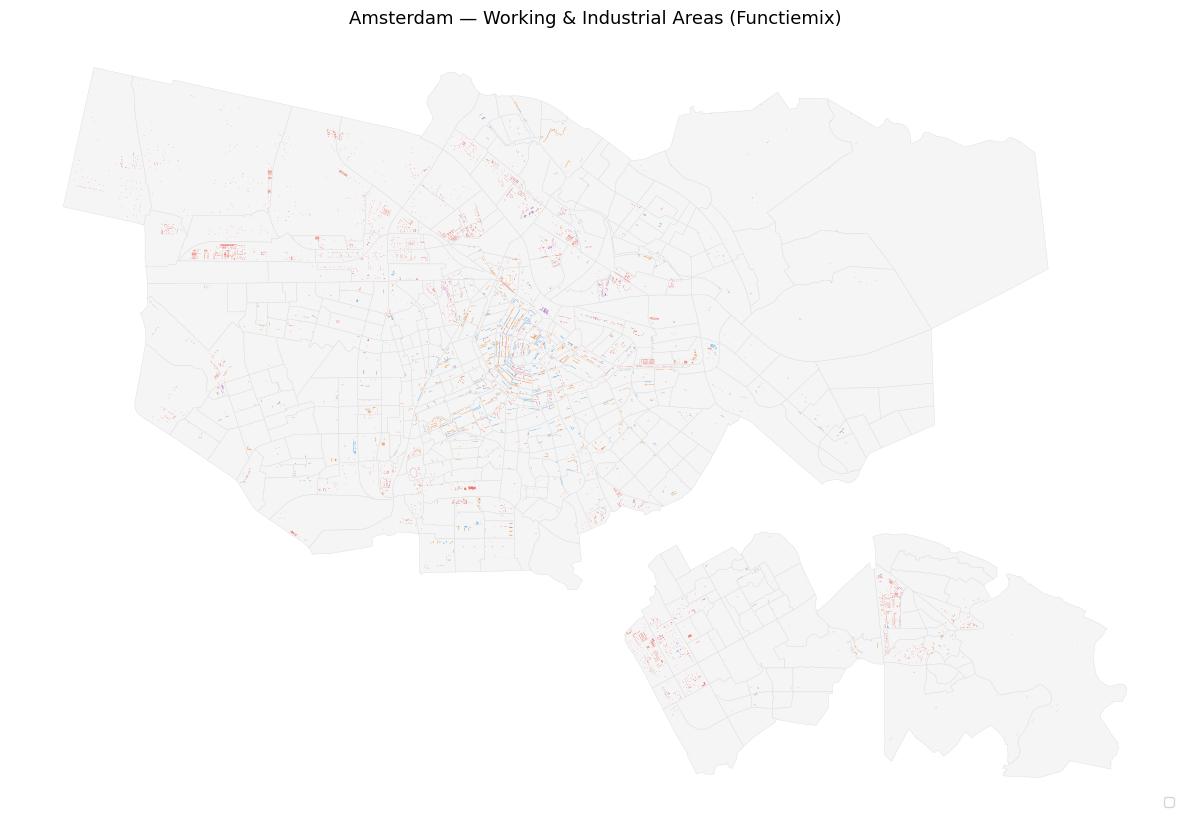

In [4]:
buurten = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\geojson_lnglat_2.json")
buurten_proj = buurten.to_crs("EPSG:28992")

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Sfondo
buurten_proj.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

# Zone per categoria con colori diversi
colori_cat = {
    'WRK': '#e74c3c',
    'WON_WRK': '#e67e22',
    'VZN_WRK': '#9b59b6',
    'GEMENGD': '#3498db'
}

for cat, colore in colori_cat.items():
    subset = wrk[wrk['CAT'] == cat]
    if len(subset) > 0:
        subset.plot(ax=ax, color=colore, alpha=0.7, label=cat)

ax.legend(fontsize=9, loc='lower right')
ax.set_title('Amsterdam — Working & Industrial Areas (Functiemix)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_industrial_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Aggreghiamo per Stadsdeel
functiemix_proj = functiemix.copy()
joined = gpd.sjoin(functiemix_proj, buurten_proj[['Stadsdeel', 'geometry']], 
                   how='left', predicate='intersects')

industria_stadsdeel = joined.groupby('Stadsdeel').agg(
    WRK_totale=('WRK', 'sum'),
    WON_totale=('WON', 'sum'),
    TOTALE=('TOTAAL', 'sum')
).reset_index()

industria_stadsdeel['WRK_perc'] = (
    industria_stadsdeel['WRK_totale'] / industria_stadsdeel['TOTALE'] * 100
).round(1)

print(industria_stadsdeel[['Stadsdeel', 'WRK_perc']].sort_values('WRK_perc', ascending=False))

    Stadsdeel  WRK_perc
6   Westpoort      97.6
4       Weesp      44.6
8    Zuidoost      38.9
1  Nieuw-West      31.1
2       Noord      27.2
0     Centrum      25.9
7        Zuid      25.8
3        Oost      21.5
5        West      19.7


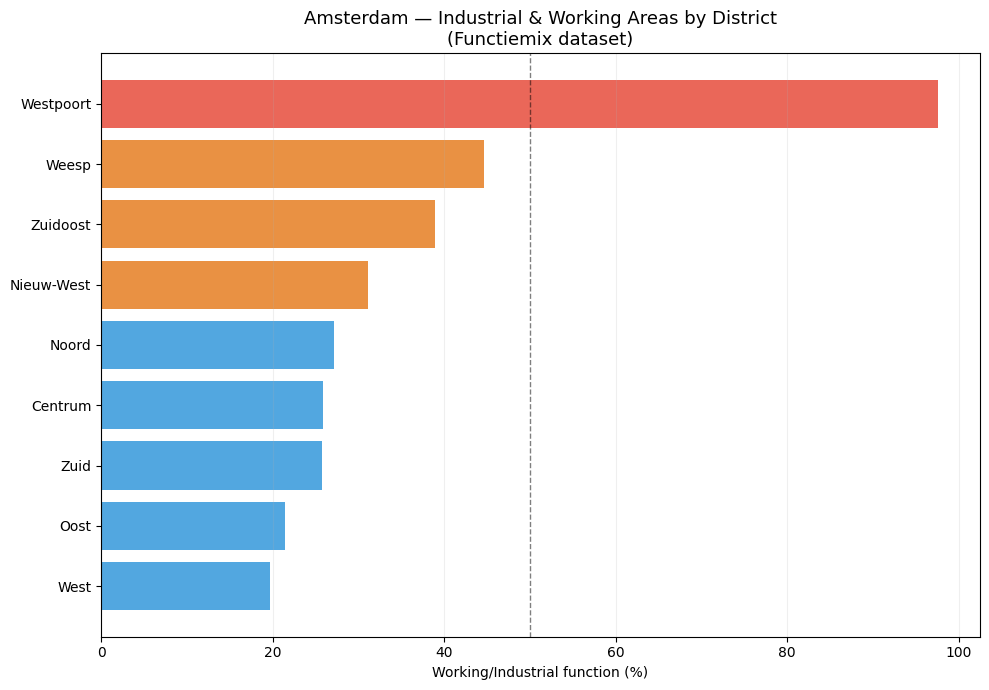

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

stadsdeel_plot = industria_stadsdeel.sort_values('WRK_perc', ascending=True)

colori = ['#e74c3c' if v > 50 else '#e67e22' if v > 30 else '#3498db' 
          for v in stadsdeel_plot['WRK_perc']]

ax.barh(stadsdeel_plot['Stadsdeel'], stadsdeel_plot['WRK_perc'],
        color=colori, alpha=0.85)

ax.axvline(x=50, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Working/Industrial function (%)')
ax.set_title('Amsterdam — Industrial & Working Areas by District\n(Functiemix dataset)', fontsize=13)
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('amsterdam_industrial_chart.png', dpi=150, bbox_inches='tight')
plt.show()

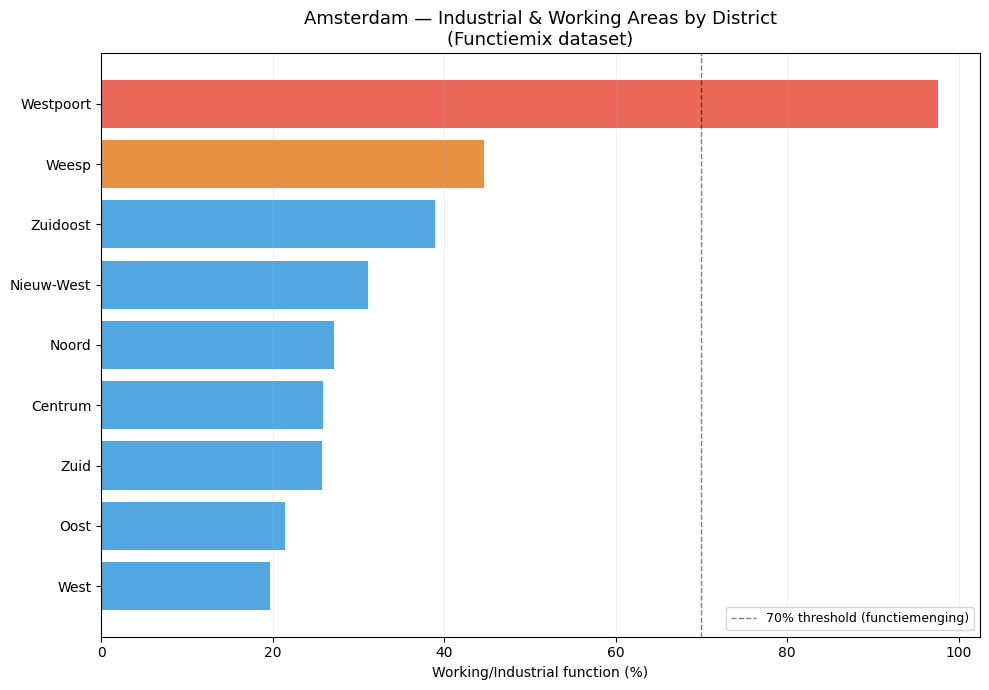

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

stadsdeel_plot = industria_stadsdeel.sort_values('WRK_perc', ascending=True)

# Soglia al 70% — motivata dal concetto olandese di functiemenging
colori = ['#e74c3c' if v > 70 else '#e67e22' if v > 40 else '#3498db' 
          for v in stadsdeel_plot['WRK_perc']]

ax.barh(stadsdeel_plot['Stadsdeel'], stadsdeel_plot['WRK_perc'],
        color=colori, alpha=0.85)

ax.axvline(x=70, color='black', linestyle='--', linewidth=1, alpha=0.5, label='70% threshold (functiemenging)')
ax.set_xlabel('Working/Industrial function (%)')
ax.set_title('Amsterdam — Industrial & Working Areas by District\n(Functiemix dataset)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('amsterdam_industrial_chart.png', dpi=150, bbox_inches='tight')
plt.show()